In [9]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scipy as sp
from pathlib import Path
import sys
import harmonypy as hm
sys.path.insert(0, "..")
import utils as ut

In [4]:
QCDir = Path("../../result/qc/qc.h5ad")
adata = sc.read_h5ad(QCDir)

In [5]:
# library size normalization + log1p transform
sc.pp.normalize_total(adata, target_sum=None)
sc.pp.log1p(adata)
print("Normalization done")

Normalization done


In [ ]:
# pca and harmony
sc.pp.pca(adata)

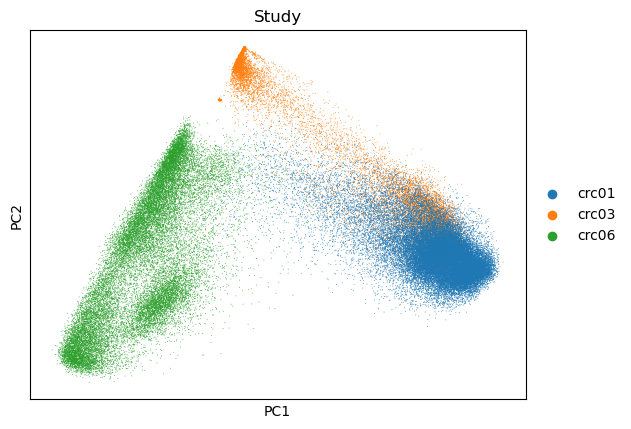

In [7]:
sc.pl.pca(adata,color = 'Study')

In [10]:
# Get PCs from the AnnData object
pcs = adata.obsm['X_pca']
print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
harmony_out = hm.run_harmony(pcs, adata.obs, "Study")

# Store corrected PCs back in the AnnData object
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr

# Use harmonized PCs for downstream analysis
sc.pp.neighbors(adata, use_rep='X_pca_harmony')
sc.tl.umap(adata)
sc.tl.leiden(adata)

2026-08-12 19:00:37,123 - harmonypy - INFO - Running Harmony
2026-08-12 19:00:37,124 - harmonypy - INFO -   Parameters:
2026-08-12 19:00:37,124 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-12 19:00:37,124 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-12 19:00:37,124 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-12 19:00:37,124 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-12 19:00:37,124 - harmonypy - INFO -     nclust: 100
2026-08-12 19:00:37,125 - harmonypy - INFO -     block_size: 0.05
2026-08-12 19:00:37,125 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-12 19:00:37,125 - harmonypy - INFO -     theta: [2. 2. 2.]
2026-08-12 19:00:37,125 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-12 19:00:37,125 - harmonypy - INFO -     verbose: True
2026-08-12 19:00:37,126 - harmonypy - INFO -     random_state: 0
2026-08-12 19:00:37,126 - harmonypy - INFO -   Data: 50 PCs × 80036 cells
2026-08-12 19:00:37,126 - harmonypy - INFO -   

(80036, 50)


2026-08-12 19:00:38,752 - harmonypy - INFO - Iteration 1 of 10
2026-08-12 19:00:39,740 - harmonypy - INFO - Iteration 2 of 10
2026-08-12 19:00:40,813 - harmonypy - INFO - Iteration 3 of 10
2026-08-12 19:00:41,869 - harmonypy - INFO - Iteration 4 of 10
2026-08-12 19:00:42,979 - harmonypy - INFO - Iteration 5 of 10
2026-08-12 19:00:44,107 - harmonypy - INFO - Iteration 6 of 10
2026-08-12 19:00:45,169 - harmonypy - INFO - Iteration 7 of 10
2026-08-12 19:00:46,234 - harmonypy - INFO - Iteration 8 of 10
2026-08-12 19:00:47,360 - harmonypy - INFO - Converged after 8 iterations
/tmp/ipykernel_651122/396755807.py:14: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igr

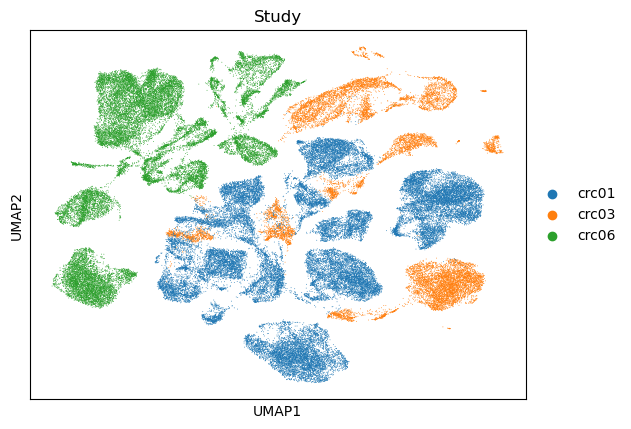

In [13]:
sc.pl.umap(adata,color="Study")